# KGBN toy workflow

This compact example follows the same vocabulary as the manuscript workflow: identifying and standardizing model inputs, extending the model via a knowledge graph, representing alternatives as a probabilistic Boolean network, optimizing with experimental data, and simulating/evaluating the optimized model.

## 1. Identifying and standardizing models, genes, phenotypes, and experimental data

Start with a small curated Boolean model and explicit gene symbols. The toy experimental readout measures `MYC` under a fixed `TP53` stimulus.

In [1]:
import numpy as np
import pandas as pd
import KGBN

base_model = """
TP53 = TP53
CDKN2A = CDKN2A
MYC = !TP53
"""

bn = KGBN.load_network(base_model, initial_state={"TP53": 1, "CDKN2A": 1, "MYC": 0})
genes = list(bn.nodeDict.keys())
experiments = [
    {
        "id": "tp53_on",
        "stimuli": ["TP53"],
        "stimuli_efficacy": [1.0],
        "inhibitors": [],
        "inhibitors_efficacy": [],
        "measurements": {"MYC": 0.2},
        "measured_formula": None,
        "measured_value": None,
    }
]
genes

Initial state set from dictionary. Genes not specified default to 0.
Network loaded successfully. There are 3 genes in the network.


['TP53', 'CDKN2A', 'MYC']

## 2. Extending the model via knowledge graphs

Query the bundled SIGNOR resource for a small KG-derived regulatory subnetwork around the same standardized gene symbols.

In [2]:
kg_string, kg_relations = KGBN.load_signor_network(
    genes,
    joiner="inhibitor_wins",
    score_cutoff=0.5,
)
print(kg_string)
kg_bn = KGBN.load_network(kg_string)

Applied score cutoff 0.5, filtered to 19342/40940 edges
number of genes found: 3
[7157, 1029, 4609]
CDKN2A = !MYC # Scores: MYC_inhibit:0.765
CSNK2A1 = CSNK2A1
MYC = !CSNK2A1 # Scores: CSNK2A1_inhibit:0.504
TP53 = CSNK2A1 # Scores: CSNK2A1_activate:0.668
No initial state provided, using a random initial state
Network loaded successfully. There are 4 genes in the network.


## 3. Probabilistic Boolean Network extension

Introduce KG-derived alternative rules for `MYC` while retaining the original curated rule as another candidate rule.

In [3]:
pbn_string = KGBN.extend_networks(
    bn,
    kg_bn,
    nodes_to_extend=["MYC"],
    prob=0.5,
    descriptive=True,
)
print(pbn_string)
pbn = KGBN.load_network(pbn_string, initial_state={"TP53": 1, "CDKN2A": 1, "MYC": 0})

Nodes affected: ['CDKN2A', 'CSNK2A1', 'MYC']

Gene: CDKN2A
  Original rule: CDKN2A
  Added rule: !MYC, 0.5

Gene: CSNK2A1
  Not present in original network
  Added rule: CSNK2A1, 1

Gene: MYC
  Original rule: !TP53
  Added rule: !CSNK2A1, 0.5
CDKN2A = !MYC, 0.5
CDKN2A = CDKN2A, 0.5
CSNK2A1 = CSNK2A1, 1.0
MYC = !CSNK2A1, 0.5
MYC = !TP53, 0.5
TP53 = TP53, 1.0
Initial state set from dictionary. Genes not specified default to 0.
PBN loaded successfully. There are 4 genes in the network.


## 4. Optimizing the PBN using experimental data

For a tiny notebook run, evaluate the optimization objective directly. For a full run, use `KGBN.ParameterOptimizer` with the same experiment structure.

In [4]:
from KGBN.simulation_evaluator import SimulationEvaluator

nodes_to_optimize = [node for node, idx in pbn.nodeDict.items() if pbn.nf[idx] > 1]
evaluator = SimulationEvaluator(
    pbn,
    experiments,
    nodes_to_optimize=nodes_to_optimize,
    config={
        "seed": 1,
        "steady_state": {
            "method": "monte_carlo",
            "monte_carlo_params": {"n_runs": 3, "n_steps": 100, "p_noise": 0.0},
        },
    },
)

candidate_parameters = np.ones(sum(pbn.nf[pbn.nodeDict[n]] for n in nodes_to_optimize))
candidate_mse = evaluator.objective_function(candidate_parameters)
candidate_mse

0.09597846981930024

## 5. Simulating and evaluating the optimized model

Compute a steady-state estimate and convert node activity into phenotype scores using the bundled ProxPath-derived phenotype resource.

In [5]:
calc = KGBN.SteadyStateCalculator(pbn)
steady_state = calc.compute_steady_state(method="monte_carlo", n_runs=5, n_steps=200)

scores = KGBN.phenotype_scores(
    genes=list(pbn.nodeDict.keys()),
    simulation_results=steady_state,
    network=pbn,
    phenotypes=["APOPTOSIS", "PROLIFERATION"],
)
pd.DataFrame(steady_state.reshape(1, -1), columns=pbn.nodeDict.keys()), scores

Path found for 2 phenotypes: ['APOPTOSIS' 'PROLIFERATION']


(     CDKN2A  CSNK2A1       MYC  TP53
 0  0.465347      0.0  0.514851   1.0,
          APOPTOSIS  PROLIFERATION
 State_1   1.465347      -0.950495)

## Visualization

Use static visualization in notebooks, or set `interactive=True` and provide an HTML output path when you want a browser-based network.

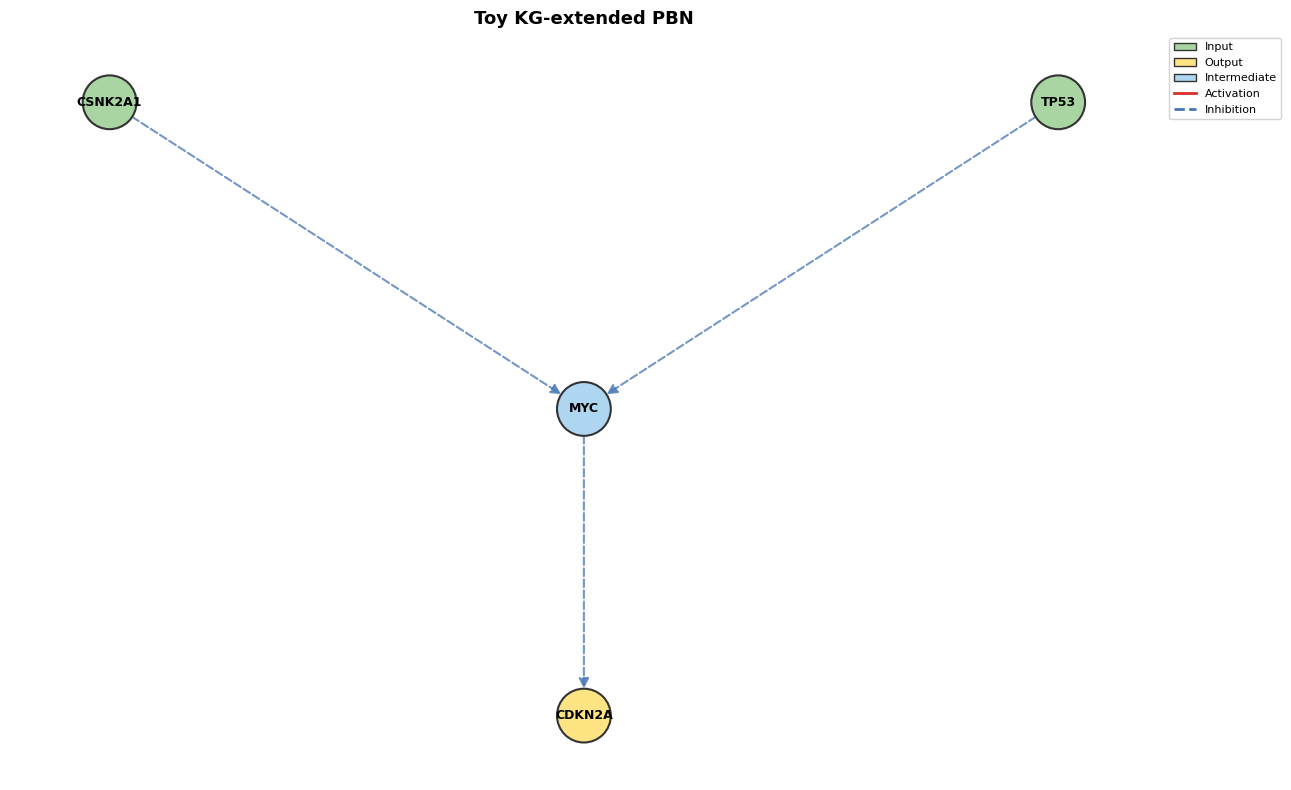

In [6]:
KGBN.vis_network(pbn, interactive=False, title="Toy KG-extended PBN")